In [1]:
from pathlib import Path
import numpy as np
import wedme.apply.dev
import matplotlib.pyplot as plt
from ramlab.raman.common import wigner_3j
from ramlab.calculate_molecules import State, Transitions
from ramlab.calculate_molecules.NO import NO
import toddler
from ramlab.simulate_spectrum import simulate_convolution

import toddler.physics
import toddler.physics.light

In [2]:
spectra_lepard = np.genfromtxt("/Users/mruijzendaal/Projects/UM/ramlab/tests/NO/spectrum_NO_lepard1970.csv", skip_header=2, delimiter=",", )
# This was taken with polarisation parallel to the scattering plane, 

shift_lepard = spectra_lepard[:, 0]
I_lepard = spectra_lepard[:, 1]


shift_lepard_electronic = spectra_lepard[:, 2]
I_lepard_electronic = spectra_lepard[:, 3]
I_lepard_electronic -= np.nanmin(I_lepard_electronic)

In [3]:
transitions = NO.all_transitions(532e-9, True)

Generating linelist file...
Discarded 2 invalid transitions
Depolarization ratio complete


In [5]:
idx = (transitions.dv == 0)
idx &= (transitions.initial_v == 0)
idx &= (transitions.initial_E < 10e3)
idx &= (transitions.initial_J < 50)
# idx &= ((transitions.final_J - transitions.initial_J) == 2)
idx &= (transitions.initial_F == 1)
idx &= (transitions.final_F == 2)
# idx &= (transitions.initial_p == 1)
# idx &= (transitions.final_p == 1)


# idx &= (transitions.dO == 1)
# idx &= (transitions.dJ == -2)
idx &= (transitions.vacuum_wavenumber > 0) & (transitions.vacuum_wavenumber < 200)

transitions_filtered = transitions[idx]
# transitions_filtered.initial_O = np.abs(transitions_filtered.initial_O)
# transitions_filtered.final_O = np.abs(transitions_filtered.final_O)
# transitions_filtered.dO = transitions_filtered.final_O - transitions_filtered.initial_O
print(f"Reduced transitions from {len(transitions)} to {len(transitions_filtered)}")

I = NO.get_intensity(transitions_filtered, 532e-9, polarisation=None, T=300)

Reduced transitions from 2990 to 500


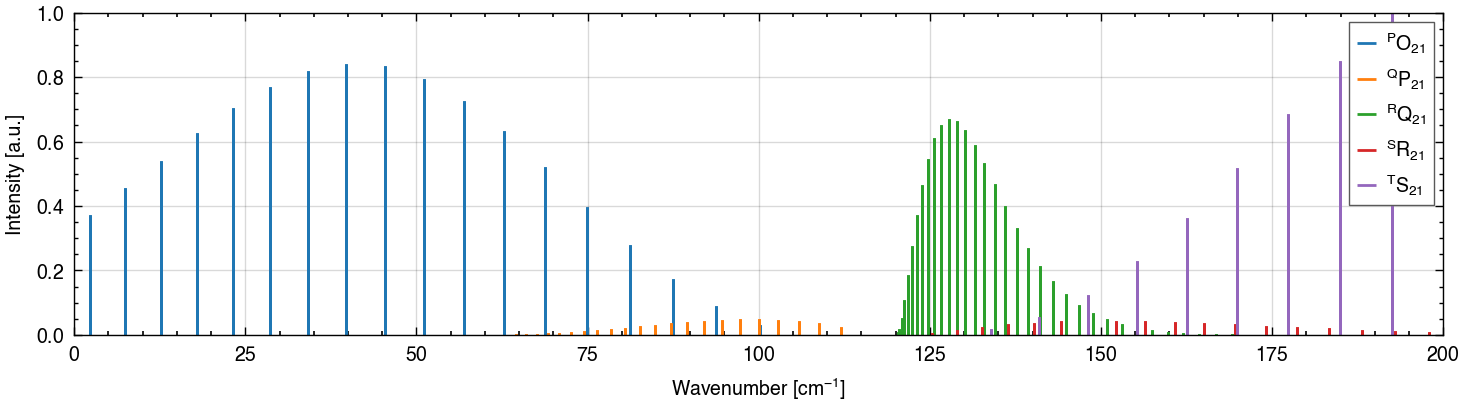

In [6]:
from itertools import cycle

from ramlab.raman.common import branchname


wedme.figure.paper_fw_dh(dpi=200)
plt.plot(0, np.nan, label=None)
# plt.vlines(shift_lepard_electronic, np.zeros_like(I_lepard), I_lepard_electronic*30, 'k', label="Lepard")
plotstyles = cycle(plt.cm.tab10.colors)

# for dF in [1]:
for dF in [-1, 0, 1]:
    idx_dO = ((transitions_filtered.final_F - transitions_filtered.initial_F) == dF)
    for F in [1, 2]:
        idx_O = np.equal(np.abs(transitions_filtered.initial_F), F)
        # for dJ in [0]:
        for dJ in [-2, -1, 0, 1, 2]:
        # for dJ in [-1, 1]:
            idx_dJ = (transitions_filtered.dJ == dJ)
            idx = idx_dO & idx_O & idx_dJ
            transitions_x = transitions_filtered[idx]
            if (not np.any(idx)) or np.all(np.isnan(I[idx])) or np.all(I[idx] == 0):
                # print(f"No transitions for O={O}, dJ={dJ}, dO={dO}")
                continue

            # print(transitions_x)
            I_x = I[idx] 
            I_x /= np.nanmax(I)
            I_x[I_x == 0] = np.nan

            dN = dJ + dF
            label_dJ = branchname(dJ)
            label_dN = branchname(dN)
            # label_pi = "e" if transitions_x.initial_p == 1 else "f"
            # label_pf = "e" if transitions_x.final_p == 1 else "f"
            label = rf"$^{label_dN}{label_dJ}_{{{F+dF}{F}}}$"

            # plt.vlines(transitions_x.vacuum_wavenumber, np.zeros_like(I_x), I_x, label=f"O={O}, dJ={dJ}", color=next(plotstyles))
            # plt.vlines(transitions_x.vacuum_wavenumber, I_x, 'o', label=rf"$\Omega_i=\frac{{{int(O*2)}}}{{2}}$, $\Delta\Omega={dO}$, $\Delta J$={dJ}", color='k')
            plt.vlines(transitions_x.vacuum_wavenumber, 0, I_x, label=label, color=next(plotstyles))
            # I_x_orig = I_orig[idx] / 1e25 / 1.24 * 1e82 / 0.002 * 0.7
            # I_x_orig[I_x_orig == 0] = np.nan
            # plt.plot(transitions_x.vacuum_wavenumber, I_x_orig, 'o', label=rf"$\Omega_i=\frac{{{int(O*2)}}}{{2}}$, $\Delta\Omega={dO}$, $\Delta J$={dJ}", color=next(plotstyles)
    # break

# plt.vlines(shift_lepard, np.zeros_like(I_lepard), I_lepard, 'k', label="Lepard")

plt.ylim(0, 1)
plt.xlim(0,200)
plt.xlabel("Wavenumber [cm$^{-1}$]")
plt.ylabel("Intensity [a.u.]")
plt.legend()
plt.show()  

# wedme.figure.paper_fw_dh(dpi=200)
# plt.vlines(shift_electronic, np.zeros_like(intensity_electronic), intensity_electronic, 'r', label="Lepard")
# plt.vlines(transitions.vacuum_wavenumber, 0, I_yz/30, 'k', label="Sim")
# plt.xlabel("Wavenumber [cm$^{-1}$]")
# plt.ylabel("Intensity [a.u.]")
# plt.legend()
# plt.xlim(0, 200)
# # plt.vlines(shift_electronic, 0, intensity_electronic, 'k', label="Lepard")
# plt.show()

In [7]:
dnu_stick = transitions_filtered.vacuum_wavenumber
I_stick = I
dnu_sim = np.linspace(np.min(dnu_stick), np.max(dnu_stick), 3000)
# I_sim = simulate_raw(dnu_sim, dnu_stick, I_stick, 0.2, 0.2, N_bin=1)
I_sim = simulate_convolution(dnu_sim, dnu_stick, I_stick, 0.2, 0.2)
I_sim /= np.nanmax(I_sim)

7.901223991494194e-15


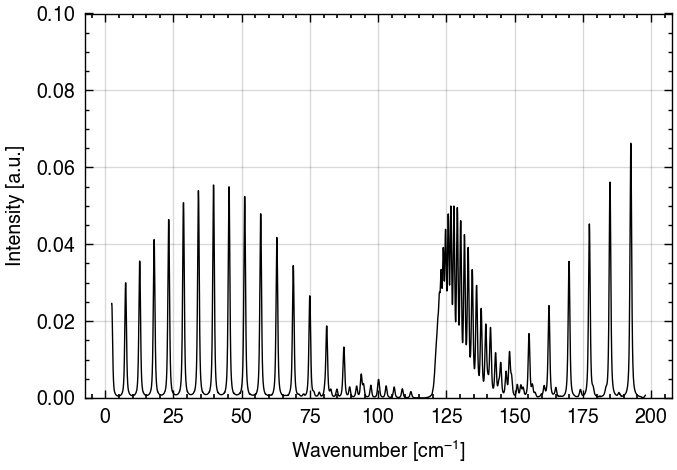

In [8]:
wedme.figure.dev()
plt.plot(dnu_sim, I_sim*0.053 / 0.8, linewidth=0.5, color='k')
# plt.vlines(dnu_stick, 0, I_stick / np.nanmax(I_stick), 'k', linewidth=0.5)
plt.ylim(0, 0.1)
plt.xlabel("Wavenumber [cm$^{-1}$]")
plt.ylabel("Intensity [a.u.]")
plt.show()

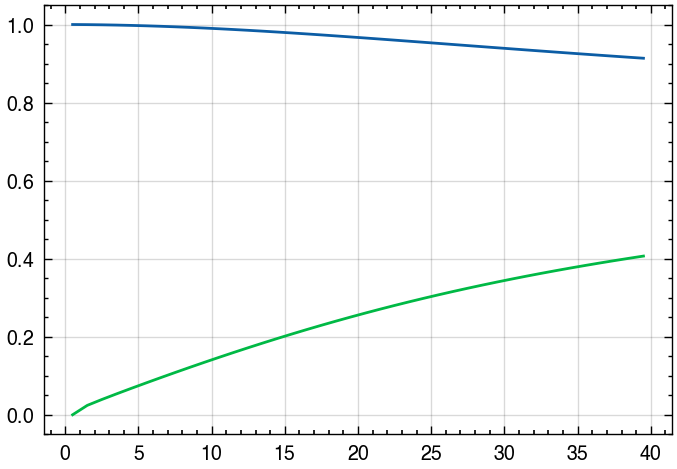

In [9]:
J = np.arange(1/2, 80/2)
plt.figure()
plt.plot(J, NO._rc(State(J=J, v=0, F=1), type="a"), label="a")
plt.plot(J, NO._rc(State(J=J, v=0, F=1), type="b"), label="b")

<Figure size 708x500 with 0 Axes>

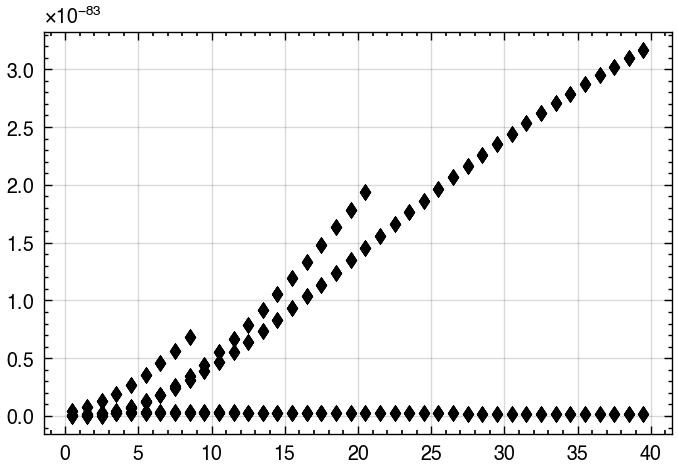

In [11]:
ayz = NO.ayz_sq_perturbed(transitions_filtered) * NO.a_q0**2 # / (2*transitions_filtered.initial_J+1)
# ayz *= 14 / np.nanmax(ayz)

wedme.figure.dev()
plt.figure()
plt.plot(transitions_filtered.initial_J, ayz, 'kd')

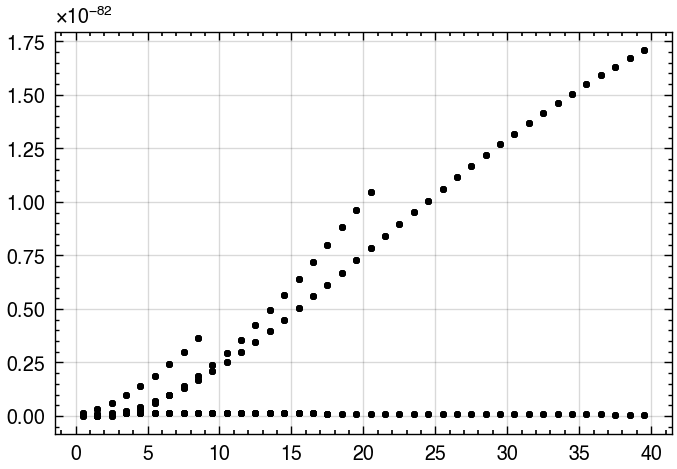

In [12]:


Ji = transitions_filtered.initial_J
Jf = transitions_filtered.final_J

# Find the a and b components of the initial and final states
aji = NO._rc(transitions_filtered.state_initial, type="a")
bji = NO._rc(transitions_filtered.state_initial, type="b")
cjf = NO._rc(transitions_filtered.state_final, type="c")
djf = NO._rc(transitions_filtered.state_final, type="d")

Szy = (2*Jf+1)/5 * NO.a_q0**2 * (aji*cjf*wigner_3j(Ji, Jf, 2, 1/2, -1/2, 0) + bji*djf*wigner_3j(Ji, Jf, 2, 3/2, -3/2, 0))**2 
Szy = Szy / 4 * 2.7

wedme.figure.dev()
# plt.plot(transitions_filtered.initial_J, ayz_sq_perturbed(transitions_filtered)*NO.a_q0**2, 'ro')
plt.plot(transitions_filtered.initial_J, Szy, 'k.')

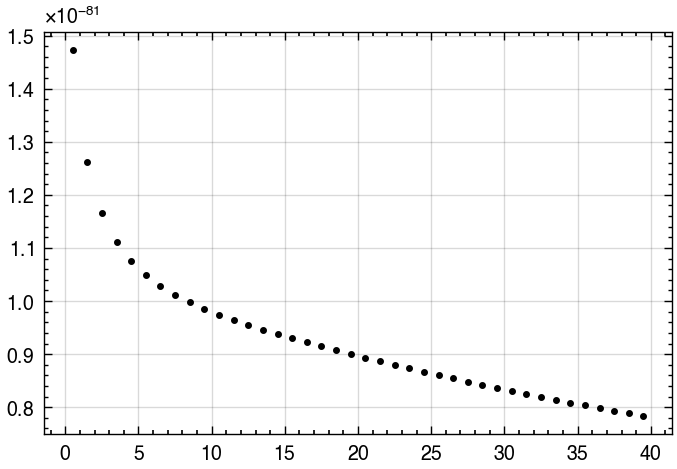

In [13]:
Ji = np.arange(1/2, 80/2)
Jf = Ji + 2

aji = NO._rc(State(J=Ji, v=0, F=1), type="a")
ajf = NO._rc(State(J=Jf, v=0, F=1), type="a")

Szy = 3 * (2*Ji +3) * (2*Ji+5) / (320 * (Ji + 2) * (Ji + 1)) * (aji * ajf) * NO.a_q0 ** 2 * 2.7

wedme.figure.dev()
plt.plot(Ji, Szy, 'k.')
# plt.ylim(0, 15e-82)
plt.show()